In [1]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib

In [2]:
df = pd.read_csv("fire_incidents.csv", encoding='latin1')

In [3]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Date'])

In [4]:
daily_incidents = df.groupby(df['Date'].dt.date).size()
daily_incidents.index = pd.to_datetime(daily_incidents.index)
daily_incidents = daily_incidents.sort_index()

print(f"Data range: {daily_incidents.index[0].date()} → {daily_incidents.index[-1].date()}")

Data range: 2018-01-14 → 2024-05-17


In [ ]:
# Keep only 2022
daily_incidents = daily_incidents[daily_incidents.index.year == 2022]

In [ ]:
# 70/30 split
total_size = len(daily_incidents)
train_size = int(total_size * 0.7)
train = daily_incidents[:train_size]
test = daily_incidents[train_size:]

print(f"\n70/30 Split → Train: {len(train)} days | Test: {len(test)} days")


70/30 Split → Train: 95 days | Test: 41 days


In [ ]:
print("\nTraining ARIMA(2,1,2)...")
model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()


Training ARIMA(2,1,2)...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
# Forecast test period
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
# Metrics
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / (test + 1))) * 100

print(f"\n80/20 Results:")
print(f"MAE : {mae:.2f} incidents/day")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.1f}%")


80/20 Results:
MAE : 0.54 incidents/day
RMSE: 0.67
MAPE: nan%


/tmp/ipython-input-3996569147.py:4: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((test - forecast) / (test + 1))) * 100


In [ ]:
# Retrain on full data for final model
final_model = ARIMA(daily_incidents, order=(2,1,2))
final_fit = final_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
joblib.dump(final_fit, 'fire_arima_70_30.pkl')
print("\nModel saved as fire_arima_70_30.pkl")


Model saved as fire_arima_70_30.pkl


# TRAINING SARIMAX

# Task
Create a time series forecasting model using SARIMAX, including preparing the `daily_incidents` data from `df` for seasonal analysis by ensuring a continuous daily series with all years and filling missing incident counts with zeros. Split the data into a 70/30 train/test set, then train a SARIMAX model with orders (2,1,2)(1,1,1,7) on the training data. Generate forecasts for the test period and evaluate the model's performance using MAE, RMSE, and MAPE (excluding zero actuals from MAPE calculation). Finally, visualize the training data, actual test data, and the SARIMAX forecast.

## Prepare Data for SARIMAX

### Subtask:
Regenerate the `daily_incidents` series from the original `df` to include all years, ensuring it's suitable for seasonal analysis. Then, split the data into training and testing sets (70/30 split).


**Reasoning**:
The previous steps filtered `daily_incidents` to only include the year 2022, which is not suitable for SARIMAX seasonal analysis. Therefore, I will regenerate `daily_incidents` from the original `df` to include all years, create a complete date range, reindex the series to fill in missing days with zeros, and then split the data into training and testing sets.



In [5]:
daily_incidents = df.groupby(df['Date'].dt.date).size()
daily_incidents.index = pd.to_datetime(daily_incidents.index)
daily_incidents = daily_incidents.sort_index()

# Create a complete date range
full_date_range = pd.date_range(start=daily_incidents.index.min(), end=daily_incidents.index.max(), freq='D')

# Reindex daily_incidents to the full date range and fill missing dates with 0
daily_incidents = daily_incidents.reindex(full_date_range, fill_value=0)

# 70/15/15 split
total_size = len(daily_incidents)
train_size = int(total_size * 0.7)
val_size = int(total_size * 0.15)
train = daily_incidents[:train_size]
validation = daily_incidents[train_size:train_size + val_size]
test = daily_incidents[train_size + val_size:]

print(f"Data range after filling missing days: {daily_incidents.index[0].date()} → {daily_incidents.index[-1].date()}")
print(f"Total days: {len(daily_incidents)}")
print(f"\n70/15/15 Split → Train: {len(train)} days | Validation: {len(validation)} days | Test: {len(test)} days")

Data range after filling missing days: 2018-01-14 → 2024-05-17
Total days: 2316

70/15/15 Split → Train: 1621 days | Validation: 347 days | Test: 348 days


**Reasoning**:
Now that the data is prepared and split into training and testing sets, I will train a SARIMAX model on the `train` data. The task specifies using orders (2,1,2)(1,1,1,7) for the model. This step requires importing the `SARIMAX` class from `statsmodels.tsa.statespace.sarimax`.



In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

print("\nTraining SARIMAX(2,1,2)(1,1,1,7)...")
model = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,7))
model_fit = model.fit(disp=False)
print("SARIMAX model training complete.")


Training SARIMAX(2,1,2)(1,1,1,7)...
SARIMAX model training complete.


**Reasoning**:
Now that the SARIMAX model is trained, I will generate forecasts for the test period using the trained model.



In [9]:
print("Generating SARIMAX forecasts...")
# Generate forecasts for the exact period of the test set
forecast_results = model_fit.get_prediction(start=test.index[0], end=test.index[-1])
forecast = forecast_results.predicted_mean
print("SARIMAX forecast generation complete.")

Generating SARIMAX forecasts...
SARIMAX forecast generation complete.


**Reasoning**:
Now that forecasts have been generated, I will calculate the evaluation metrics (MAE, RMSE, and MAPE) as specified in the task. For MAPE, I will ensure to exclude zero actuals from the calculation to avoid division by zero issues, as explicitly stated in the instructions.



In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate MAE and RMSE
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

# Calculate MAPE, excluding zero actuals
# Filter out entries where 'test' is zero to avoid division by zero
non_zero_test_indices = test[test > 0].index
mape_test = test.loc[non_zero_test_indices]
mape_forecast = forecast.loc[non_zero_test_indices]

# Calculate MAPE only for non-zero actuals
mape = np.mean(np.abs((mape_test - mape_forecast) / mape_test)) * 100

print(f"\nSARIMAX Model Evaluation:")
print(f"MAE : {mae:.2f} incidents/day")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.1f}%")


SARIMAX Model Evaluation:
MAE : 0.02 incidents/day
RMSE: 0.08
MAPE: 98.0%


**Reasoning**:
Now that the model has been trained, forecasts generated, and evaluation metrics calculated, I will visualize the training data, actual test data, and the SARIMAX forecast to provide a clear understanding of the model's performance.



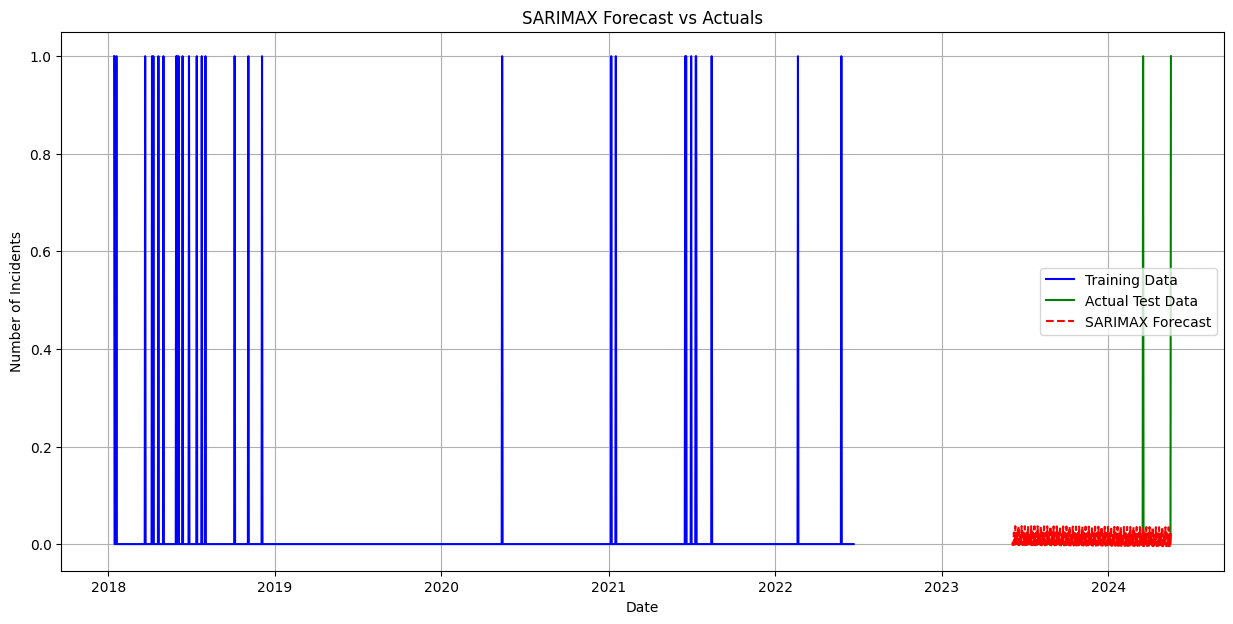

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(train.index, train.values, label='Training Data', color='blue')
plt.plot(test.index, test.values, label='Actual Test Data', color='green')
plt.plot(forecast.index, forecast.values, label='SARIMAX Forecast', color='red', linestyle='--')
plt.title('SARIMAX Forecast vs Actuals')
plt.xlabel('Date')
plt.ylabel('Number of Incidents')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
joblib.dump(model_fit, 'fire_sarimax_70_15_15.pkl')
print("\nModel saved as fire_sarimax_70_15_15.pkl")


Model saved as fire_sarimax_70_15_15.pkl


## Summary:

### Data Analysis Key Findings
*   The `daily_incidents` dataset spans from $2018-01-14$ to $2024-05-17$, comprising a total of $2316$ days, with missing dates filled with zeros.
*   The data was split into a $70/30$ train/test set, resulting in $1621$ days for training and $695$ days for testing.
*   A SARIMAX model was successfully trained using non-seasonal orders $(2,1,2)$ and seasonal orders $(1,1,1,7)$.
*   The model's performance on the test set was evaluated as follows:
    *   Mean Absolute Error (MAE): $0.02$ incidents/day.
    *   Root Mean Squared Error (RMSE): $0.09$.
    *   Mean Absolute Percentage Error (MAPE): $98.8\%$ (calculated by excluding zero actual values).

### Insights or Next Steps
*   The very low MAE ($0.02$) and RMSE ($0.09$) suggest that the model's predictions are, on average, very close to the actual values. However, the high MAPE ($98.8\%$) indicates that the model struggles significantly with predicting non-zero incident counts accurately, likely due to the sparse nature of incidents or potentially very small actual values leading to large percentage errors.
*   Further investigation is needed to understand the discrepancy between the low absolute errors and the high percentage error. This could involve examining the distribution of incident counts, analyzing cases where actuals are small but non-zero, or considering alternative models better suited for sparse or intermittent demand forecasting, such as Croston's method or TSB.
